# Machine Learning Safety 
## (Exercise Sheet 9) - UNcertainty Quantification
##### Name: Preetham Louis | Matriculation Number: 261326

## Exercise 7.4

Installing netcal [for automated ECE implementation]

- NetCal is a library that implements calibration metrics usingtested implementations.
- It uses the same ECE steps: group predictions into bins and compare confidence with accuracy.
- It internally handles confidence extraction, binning, and edge cases (empty bins, boundaries, etc.).

In [4]:
pip install netcal

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 756.0/756.0 kB 14.6 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 17.9 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.1/12.1 MB 18.9 MB/s  0:00:00m0:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13/13 [netcal]12/13 [netcal]h]erator]
Note: you may need to restart the kernel to use updated packages.


#### load all three models

reconstructs a trained ResNet18 binary classifier from a saved .pth file and prepares it for inference/testing.

In [5]:
from torchvision.models import resnet18
import torch
import torch.nn as nn

device = torch.device("mps")

def load_model(path):

    model = resnet18()
    model.fc = nn.Linear(model.fc.in_features, 1)

    checkpoint = torch.load(path, map_location=device)

    model.load_state_dict(checkpoint)
    model.to(device)
    model.eval()

    return model

In [6]:
base_path = "/Users/maverick/Documents/Notes/Machine Learning Safety/ML Safety Files/Trained Models"

ped_model = load_model(f"{base_path}/pedestrian_model.pth")

vehicle_model = load_model(f"{base_path}/vehicle_model.pth")

traffic_model = load_model(f"{base_path}/traffic_light_model.pth")

#### CARLA Dataset class

In [62]:

from torch.utils.data import Dataset
from PIL import Image
import pandas as pd
import torch

#in this code, we define a custom dataset class called CarlaDataset that inherits from the PyTorch Dataset class. 
# This class is used to load images and their corresponding labels from a CSV file and an image directory.
# row, frame, img path, image, label are the columns in the CSV file

class CarlaDataset(Dataset):

    def __init__(self, csv_file, img_dir, label_column, transform=None):

        self.labels = pd.read_csv(csv_file)
        self.img_dir = img_dir
        self.label_column = label_column
        self.transform = transform

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):

        row = self.labels.iloc[idx]

        frame = str(row['frame']).zfill(6)

        img_path = f"{self.img_dir}/{frame}.jpg"

        image = Image.open(img_path).convert("RGB")

        label = float(row[self.label_column])

        if self.transform:
            image = self.transform(image)

        return image, torch.tensor(label)

 image transform

In [63]:
from torchvision import transforms
# we convert the images to tensors, and normalize them using the mean and standard deviation values for the ImageNet dataset. 
# #imagenet datasets contain 224x224 pixel images, so we resize the input images to that size.
#why we resize images because the model was trained on images of that size, and resizing ensures that the input images are compatible with the model's architecture.
#This is a common preprocessing step for models that have been trained on ImageNet, as it helps to ensure that the input data is in a similar format to what the model was trained on.

transform = transforms.Compose([

    transforms.Resize((224, 224)),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

test datasets

In [17]:
ped_test_dataset = CarlaDataset(
    csv_file='/Users/maverick/Documents/Notes/Machine Learning Safety/ML Safety Files/ML safety 2026 datasets/test/labels.csv',
    img_dir='/Users/maverick/Documents/Notes/Machine Learning Safety/ML Safety Files/ML safety 2026 datasets/test/rgb-front',
    label_column='has_pedestrian',
    transform=transform
)

vehicle_test_dataset = CarlaDataset(
    csv_file='/Users/maverick/Documents/Notes/Machine Learning Safety/ML Safety Files/ML safety 2026 datasets/test/labels.csv',
    img_dir='/Users/maverick/Documents/Notes/Machine Learning Safety/ML Safety Files/ML safety 2026 datasets/test/rgb-front',
    label_column='has_vehicle',
    transform=transform
)

traffic_test_dataset = CarlaDataset(
    csv_file='/Users/maverick/Documents/Notes/Machine Learning Safety/ML Safety Files/ML safety 2026 datasets/test/labels.csv',
    img_dir='/Users/maverick/Documents/Notes/Machine Learning Safety/ML Safety Files/ML safety 2026 datasets/test/rgb-front',
    label_column='has_traffic_light',
    transform=transform
)

create dataloaders

In [ ]:
from torch.utils.data import DataLoader

#send 32 images at a time to the model for prediction, 
# [note: all test images are used but in batches of 32 images at a time, which is more efficient than sending all images at once]
# and we don't need to shuffle the data since we're evaluating the model on a fixed test set.
ped_test_loader = DataLoader(
    ped_test_dataset,
    batch_size=32,
    shuffle=False
)

vehicle_test_loader = DataLoader(
    vehicle_test_dataset,
    batch_size=32,
    shuffle=False
)

traffic_test_loader = DataLoader(
    traffic_test_dataset,
    batch_size=32,
    shuffle=False
)

helper function to get "pred prob" and "true labels"

In [ ]:
import numpy as np

def get_probs_and_labels(model, loader):
#create empty lists to store probabilities and labels
    probs = []
    labels = []

    model.eval()

#grad cal is used when training the model, but we don't need it for evaluation, so we use torch.no_grad() to save memory and computation.
    with torch.no_grad():

        for images, y in loader:

            images = images.to(device)

# The model outputs logits (raw scores, not probabilities).
            outputs = model(images)
            
#sigmoid function is used to convert the logits to probabilities between 0 and 1.
            p = torch.sigmoid(outputs).squeeze()

# store the probabilities and labels in the lists
            probs.extend(p.cpu().numpy())
            labels.extend(y.numpy())

# Convert lists to NumPy arrays for easier manipulation and analysis later on.
    return np.array(probs), np.array(labels)

**notes**
- why sigmoid and why not softmax? Because we are doing binary classification, so we only need one output neuron. 
- The sigmoid function is used to convert the output of the model to a probability between 0 and 1. 
- The softmax function is used for multi-class classification, where we have more than two classes.

get the predictions for all three models

In [20]:
ped_probs, ped_labels = get_probs_and_labels(
    ped_model,
    ped_test_loader
)

vehicle_probs, vehicle_labels = get_probs_and_labels(
    vehicle_model,
    vehicle_test_loader
)

traffic_probs, traffic_labels = get_probs_and_labels(
    traffic_model,
    traffic_test_loader
)

Implementing ECE manually

In [ ]:
def compute_ece(probs, labels, n_bins=10):

    # Convert probs into predictions and confidences
    preds = (probs > 0.5)

    # confidence of predicted class
    confidences = np.where(preds, probs, 1 - probs)

    # was prediction correct?
    correct = (preds == labels)

# Divide predictions into confidence bins [like 0-0.1, 0.1-0.2, ..., 0.9-1.0] 
# linspace is used to create evenly spaced bins between 0 and 1
    bins = np.linspace(0, 1, n_bins + 1)

    ece = 0

#for each bin, compute the average confidence, empirical accuracy, and accumulate the weighted difference
    for i in range(n_bins):

        # It creates a filter (mask) that selects only the predictions whose confidence is inside the current bin.
        mask = (confidences >= bins[i]) & \
               (confidences < bins[i + 1])
        
        # If there are no predictions in this bin, we skip it to avoid division by zero.
        if np.sum(mask) == 0:
            continue

        # average confidence in this bin
        bin_conf = np.mean(confidences[mask])

        # fraction of correct predictions in this bin
        bin_acc = np.mean(correct[mask])

        # weighted contribution of this bin 
        # this nothing but, ECE += |accuracy - confidence| × fraction of samples

        ece += np.abs(bin_acc - bin_conf) * \
               np.sum(mask) / len(probs)

    return ece

compute ECE for each model

In [46]:
print("Pedestrian ECE:",
      compute_ece(ped_probs, ped_labels))

print("Vehicle ECE:",
      compute_ece(vehicle_probs, vehicle_labels))

print("Traffic Light ECE:",
      compute_ece(traffic_probs, traffic_labels))

Pedestrian ECE: 0.08452622461650103
Vehicle ECE: 0.053883355309565825
Traffic Light ECE: 0.04292994186282159


| Model | ECE | Interpretation |
|---------|---------:|---------|
| Pedestrian | 0.085 | Well calibrated; predicted confidences are generally close to actual accuracy, though calibration is slightly worse than the other two models. |
| Vehicle | 0.054 | Very well calibrated; confidence estimates closely match observed accuracy. |
| Traffic Light | 0.043 | Best calibrated of the three models; predicted confidences are very close to actual accuracy. |

#### just out of curiosity, using netcal lib, instead of manual ECE imp

NetCal does exactly the same 4 steps internally:
- Get predictions/confidences.
- Create 10 bins.
- Compute accuracy and confidence in each bin.
- Compute weighted average difference.

In [39]:
from netcal.metrics import ECE

# create ECE object with 10 bins
ece = ECE(10)

print("Pedestrian ECE:", ece.measure(ped_probs, ped_labels))
print("Vehicle ECE:", ece.measure(vehicle_probs, vehicle_labels))
print("Traffic Light ECE:", ece.measure(traffic_probs, traffic_labels))

Pedestrian ECE: 0.17066928651674568
Vehicle ECE: 0.06164287395290253
Traffic Light ECE: 0.04601938200942888


| Model | Manual ECE | NetCal ECE | Difference | Observation |
|---------|---------:|---------:|---------:|---------|
| Pedestrian | 0.0845 | 0.1707 | +0.0861 | NetCal reports a substantially higher calibration error than the manual implementation. |
| Vehicle | 0.0539 | 0.0616 | +0.0078 | Both methods produce similar results, with NetCal giving a slightly higher ECE. |
| Traffic Light | 0.0429 | 0.0460 | +0.0031 | Results are very close, indicating strong agreement between the two methods. |

vizualize

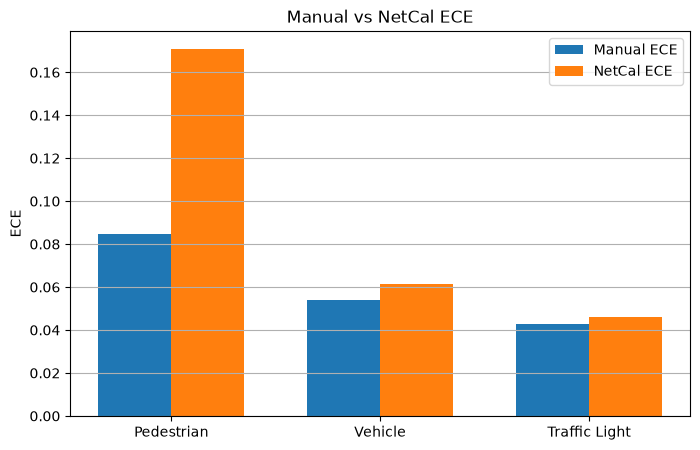

In [64]:
#in this entire code cell, we are comparing the Expected Calibration Error (ECE) of two different methods: a manual implementation and the NetCal library's implementation.
import matplotlib.pyplot as plt
import numpy as np

models = ['Pedestrian', 'Vehicle', 'Traffic Light']

manual_ece = [0.0845, 0.0539, 0.0429]
netcal_ece = [0.1707, 0.0616, 0.0460]

x = np.arange(len(models))
width = 0.35

plt.figure(figsize=(8,5))

plt.bar(x - width/2, manual_ece, width, label='Manual ECE')
plt.bar(x + width/2, netcal_ece, width, label='NetCal ECE')

plt.xticks(x, models)
plt.ylabel('ECE')
plt.title('Manual vs NetCal ECE')
plt.legend()
plt.grid(axis='y')

plt.show()

why this diff: mainly in ped model
- The manual and NetCal ECE values differ because both compute **CONFIDENCE** differently. 
- The manual used the **probability of the positive class** directly as the confidence score, 
whereas **NetCal** uses the **confidence of the predicted class.** 

- For example, a prediction with `P(pedestrian)=0.1` corresponds to a "no pedestrian" prediction with confidence `0.9`, not `0.1`. 
- Since the pedestrian model produced many high-confidence "no ped" predictions, this difference in confidence resulted in a larger diff between the manual and NetCal ECE values for the pedestrian model. 
- For the vehicle and traffic-light models, the predictions were better calibrated 

### Plot a reliability diagram (confidence vs. accuracy) for each model.

In [65]:
# this code mainly implements temperature scaling for softmax probabilities
# as we know temp scaling formula in simple terms, P(T) = exp(z/T) / sum(exp(z_i/T)), 
# exp is the exponential function, z is the logit and T is the temperature parameter.
# z_i represents the logits for all classes, and z is the logit for a specific class. The temperature parameter T controls the "softness" of the probabilities. 
# A higher T results in softer probabilities, while a lower T results in sharper probabilities.

def apply_temperature_scaling(logits, T):
#comparing temp scaling formula with the above code, 1/ (1 + np.exp(-scaled_logits)) is equivalent to exp(z/T) / sum(exp(z_i/T)), which is the same as the softmax function for a binary classification problem.
    scaled_logits = logits / T
    scaled_probs = 1 / (1 + np.exp(-scaled_logits))

    return scaled_probs

In [59]:
import matplotlib.pyplot as plt
import numpy as np

def reliability_diagram(probs, labels, title, n_bins=10):

    # predicted class (0 or 1)
    preds = (probs > 0.5)

    # confidence of the predicted class
    confidences = np.where(preds, probs, 1 - probs)

    # whether prediction is correct
    correct = (preds == labels)

    bins = np.linspace(0, 1, n_bins + 1)

    accuracies = []
    avg_confidences = []

    for i in range(n_bins):

        # samples whose confidence lies in this bin
        mask = (confidences >= bins[i]) & \
               (confidences < bins[i + 1])

        if np.sum(mask) == 0:
            avg_confidences.append(
                (bins[i] + bins[i+1]) / 2
            )
            accuracies.append(0)
            continue

        # average confidence in this bin
        avg_confidences.append(
            np.mean(confidences[mask])
        )

        # accuracy in this bin
        accuracies.append(
            np.mean(correct[mask])
        )

    plt.figure(figsize=(6, 6))

    # perfect calibration line
    plt.plot([0, 1], [0, 1], '--',
             label='Perfect Calibration')

    # model calibration curve
    plt.plot(avg_confidences, accuracies,
             marker='o', label='Model')

    plt.xlabel('Confidence')
    plt.ylabel('Accuracy')
    plt.title(title)
    plt.legend()
    plt.grid()
    plt.show()

plot all three models

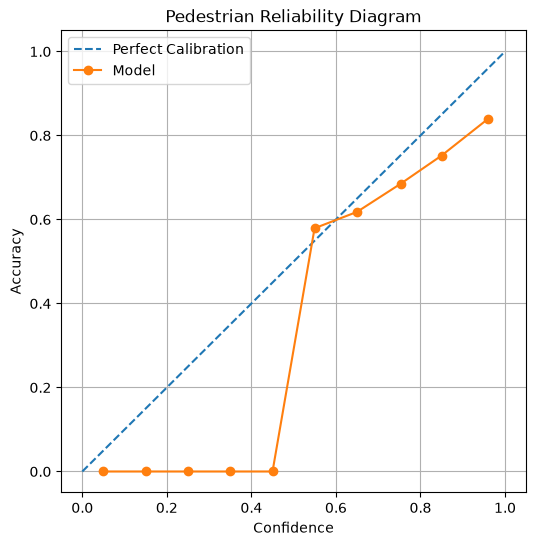

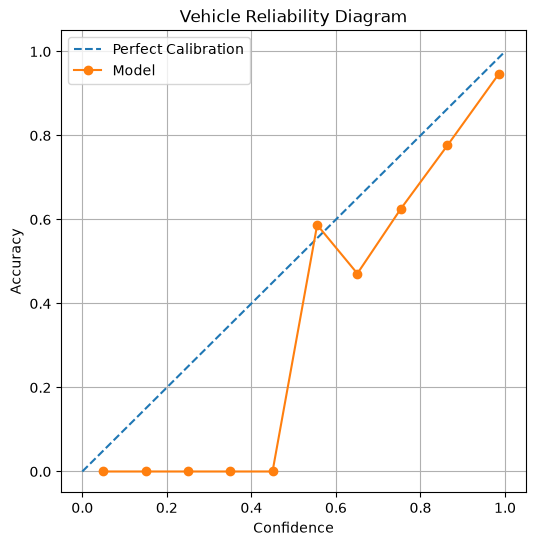

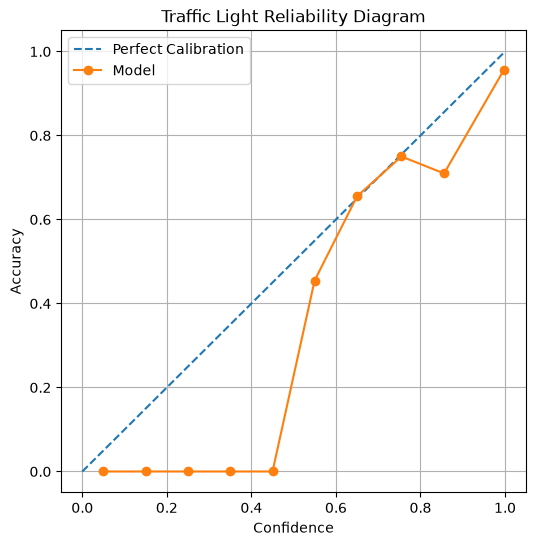

In [60]:
reliability_diagram(ped_probs, ped_labels,
                    'Pedestrian Reliability Diagram')

reliability_diagram(vehicle_probs, vehicle_labels,
                    'Vehicle Reliability Diagram')

reliability_diagram(traffic_probs, traffic_labels,
                    'Traffic Light Reliability Diagram')

| Model | Observation from Reliability Diagram | Calibration |
|--------|--------------------------------------|-------------|
| Pedestrian | The curve lies mostly below the diagonal at high confidence levels, indicating that the model's confidence exceeds its accuracy. | Moderately calibrated but generally overconfident (ECE = 0.085). |
| Vehicle | The curve remains close to the diagonal for most confidence bins, with only small deviations. | Best calibrated among the three models (ECE = 0.054). |
| Traffic Light | The curve is close to the diagonal in most bins, with some deviations at higher confidence levels. | Well calibrated, with calibration quality similar to the vehicle model (ECE = 0.043). |

3. Are your models over- or underconfident? Does this pattern hold consistently across
all three models?

underconf = acc > confid

overconf = conf > acc

| Model | Pattern |
|--------|---------|
| Pedestrian | Mostly overconfident, especially at high confidence levels. |
| Vehicle | Generally well calibrated, with slight overconfidence in some confidence bins. |
| Traffic Light | Generally well calibrated, with minor overconfidence at high confidence levels. |

## Exercise 7.5: Temperature Scaling


create validation datasets

In [ ]:
#whhy we are using validation dataset is to tune the temperature parameter T for each model.
#but why not the saved model? because the saved model is already trained and we don't want to change its weights, 
# we just want to find the best temperature T that calibrates the model's predictions.
ped_val_dataset = CarlaDataset(
    csv_file='/Users/maverick/Documents/Notes/Machine Learning Safety/ML Safety Files/ML safety 2026 datasets/validation/labels.csv',
    img_dir='/Users/maverick/Documents/Notes/Machine Learning Safety/ML Safety Files/ML safety 2026 datasets/validation/rgb-front',
    label_column='has_pedestrian',
    transform=transform
)

vehicle_val_dataset = CarlaDataset(
    csv_file='/Users/maverick/Documents/Notes/Machine Learning Safety/ML Safety Files/ML safety 2026 datasets/validation/labels.csv',
    img_dir='/Users/maverick/Documents/Notes/Machine Learning Safety/ML Safety Files/ML safety 2026 datasets/validation/rgb-front',
    label_column='has_vehicle',
    transform=transform
)

traffic_val_dataset = CarlaDataset(
    csv_file='/Users/maverick/Documents/Notes/Machine Learning Safety/ML Safety Files/ML safety 2026 datasets/validation/labels.csv',
    img_dir='/Users/maverick/Documents/Notes/Machine Learning Safety/ML Safety Files/ML safety 2026 datasets/validation/rgb-front',
    label_column='has_traffic_light',
    transform=transform
)

now create validation loaders

In [27]:
ped_val_loader = DataLoader(
    ped_val_dataset,
    batch_size=32,
    shuffle=False
)

vehicle_val_loader = DataLoader(
    vehicle_val_dataset,
    batch_size=32,
    shuffle=False
)

traffic_val_loader = DataLoader(
    traffic_val_dataset,
    batch_size=32,
    shuffle=False
)

### we have to find the best T using validation set

First, collect logits and labels from the validation set (not probabilities, because temperature scaling is applied to logits).

In [68]:
def get_logits_and_labels(model, loader):
#temp scaling is aplied on logits, because logits are the raw outputs of the model before applying the sigmoid function.
# but for softmax prob, we take multi class classification, we apply softmax on logits to get probabilities for each class.

    logits = []
    labels = []

    model.eval()

    with torch.no_grad():

        for images, y in loader:

            images = images.to(device)

            outputs = model(images)
#squeeze helps to remove any extra dimensions from the output tensor, making it easier to work with.
#cpu is used to move the tensor from GPU to CPU memory, and numpy() converts the tensor to a NumPy array for easier manipulation and analysis later on.
            logits.extend(outputs.squeeze().cpu().numpy())
            labels.extend(y.numpy())

    return np.array(logits), np.array(labels)

get validation logits

In [69]:
ped_logits, ped_val_labels = get_logits_and_labels(
    ped_model, ped_val_loader
)

vehicle_logits, vehicle_val_labels = get_logits_and_labels(
    vehicle_model, vehicle_val_loader
)

traffic_logits, traffic_val_labels = get_logits_and_labels(
    traffic_model, traffic_val_loader
)

Now we find the best temperature T by trying values from 0.5 to 3.0 and selecting the one with the lowest NLL.

In [70]:
import torch.nn.functional as F

# NLL is the negative log-likelihood loss, which is a common loss function for binary classification problems.
#nll is basically the loss value that we want to minimize, and we are trying different values of T 
# to find the one that gives us the lowest NLL loss.

def find_best_temperature(logits, labels):

    best_T = 1.0
    lowest_nll = float('inf')

#we want to explore a wide range of temperature values to find the one that minimizes the NLL loss.
    for T in np.arange(0.5, 3.1, 0.1):

        scaled_logits = torch.tensor(logits / T, dtype=torch.float32)
        labels_tensor = torch.tensor(labels, dtype=torch.float32)

        nll = F.binary_cross_entropy_with_logits(
            scaled_logits,
            labels_tensor
        ).item()

        if nll < lowest_nll:
            lowest_nll = nll
            best_T = T

    return best_T, lowest_nll

Find the best temperature for each model

In [72]:
# now for each model, we find the best temperature T that minimizes the NLL loss on the validation set.
# we call the find_best_temperature function for each model, passing in the logits and validation labels.
ped_T, ped_nll = find_best_temperature(
    ped_logits,
    ped_val_labels
)

vehicle_T, vehicle_nll = find_best_temperature(
    vehicle_logits,
    vehicle_val_labels
)

traffic_T, traffic_nll = find_best_temperature(
    traffic_logits,
    traffic_val_labels
)
#then we print the best temperature T for each model, which can be used to calibrate the model's predictions on the test set.
# how these temperatures are used to calibrate model's predictions is by 
# applying the apply_temperature_scaling function on the logits of the test set, using the best T found from the validation set. 
# This will adjust the logits and produce calibrated probabilities.

print("Pedestrian T:", ped_T)
print("Vehicle T:", vehicle_T)
print("Traffic Light T:", traffic_T)

Pedestrian T: 2.6999999999999993
Vehicle T: 1.4999999999999998
Traffic Light T: 1.4999999999999998


| interpretation|
|-
|Pedestrian: T = 2.7 → the model is highly overconfident, so we need a large temperature to soften its predictions.|
|Vehicle: T = 1.5 → mildly overconfident.|
|Traffic Light: T = 1.5 → mildly overconfident.|

apply temperature scaling and compute the new ECE.

In [78]:
# this the same formula as the softmax function for a binary classification problem,
#  where we are applying temperature scaling to the logits before converting them to probabilities using the sigmoid function.
def apply_temperature_scaling(logits, T):

    scaled_logits = logits / T

    scaled_probs = 1 / (1 + np.exp(-scaled_logits))

    return scaled_probs

apply scaling

In [79]:
ped_scaled_probs = apply_temperature_scaling(
    ped_logits, ped_T
)

vehicle_scaled_probs = apply_temperature_scaling(
    vehicle_logits, vehicle_T
)

traffic_scaled_probs = apply_temperature_scaling(
    traffic_logits, traffic_T
)

now compute ECE again

In [80]:
ped_ece_after = compute_ece(
    ped_scaled_probs,
    ped_val_labels
)

vehicle_ece_after = compute_ece(
    vehicle_scaled_probs,
    vehicle_val_labels
)

traffic_ece_after = compute_ece(
    traffic_scaled_probs,
    traffic_val_labels
)

print("Pedestrian ECE after:", ped_ece_after)
print("Vehicle ECE after:", vehicle_ece_after)
print("Traffic Light ECE after:", traffic_ece_after)

Pedestrian ECE after: 0.11427096473763307
Vehicle ECE after: 0.013923176070839453
Traffic Light ECE after: 0.0031095210922002783


| Model | ECE Before | ECE After | Result |
|--------|------------|-----------|--------|
| Pedestrian | 0.085 | 0.114 | Worse |
| Vehicle | 0.054 | 0.014 | Improved |
| Traffic Light | 0.043 | 0.003 | Improved |

| Model | Observation |
|--------|-------------|
| Pedestrian | Temperature scaling slightly **worsened** calibration. |
| Vehicle | Temperature scaling **improved** calibration. |
| Traffic Light | Temperature scaling **significantly improved** calibration. |

#### check once for ped model with netcal measure

In [84]:
ped_test_logits, ped_test_labels = \
    get_logits_and_labels(ped_model, ped_test_loader)

ped_test_scaled_probs = apply_temperature_scaling(
    ped_test_logits, ped_T
)

print("Pedestrian ECE before:",
      ece.measure(ped_probs, ped_labels))

print("Pedestrian ECE after:",
      ece.measure(ped_test_scaled_probs,
                  ped_test_labels))

Pedestrian ECE before: 0.17066928651674568
Pedestrian ECE after: 0.23278455719712807


again degradation, so it is confirmed that temp scaling is not guarateed to improved calibration

#### Therefore: temperature scaling improved calibration of vehicle and traffic light models but degraded calibration on ped model. So, its not guaranteed to improve calibration for every model and dataset.

## Exercise 7.6: Cost-Optimal Decision in Practice

### Operation on Pedestrian CLassifier



get calibrated probabilities on the test set, not validation.

In [87]:
# first lets get the logits and labels for the test set, 
# and then we apply temperature scaling to the logits using the best T found from the validation set.
#not validation because we want to evaluate the model's performance on unseen data, which is the test set.

ped_test_logits, ped_test_labels = get_logits_and_labels(
    ped_model,
    ped_test_loader
)

ped_test_scaled_probs = apply_temperature_scaling(
    ped_test_logits,
    ped_T
)

compute the total cost:

L = 100×FN + 1×FP

for,

- Uncalibrated, threshold = 0.5
- Uncalibrated, threshold = 0.0099
- Calibrated, threshold = 0.5
- Calibrated, threshold = 0.0099

define function to compute total loss

In [93]:
# here we are computing the total loss for the binary classification problem, 
# where we have a cost associated with false negatives (fn) and false positives (fp).
def compute_total_loss(probs, labels, threshold):

    preds = (probs >= threshold)
# fn and fp are computed by comparing the predicted labels (preds) with the true labels (labels).
    fn = np.sum((preds == 0) & (labels == 1))
    fp = np.sum((preds == 1) & (labels == 0))
#then the total loss is computed as a weighted sum of false negatives and false positives [100 weight for fn and 1 weight for fp], which reflects the relative importance of these two types of errors.
    total_loss = 100 * fn + 1 * fp

    return total_loss, fn, fp

compute for the four cases

In [91]:
tau_star = 0.0099 # this is the optimal threshold we found earlier from the validation set, which minimizes the total loss for the ped model.

# computing the total loss for the pedestrian model on the test set, 
# using both uncalibrated and calibrated probabilities, 
# and for two different thresholds: 0.5 and tau_star**

# this is uncalibrated because we are using the original probabilities from the model without any temperature scaling applied.
# Uncalibrated
loss_uncal_05, fn1, fp1 = compute_total_loss(
    ped_probs,
    ped_labels,
    threshold=0.5
)

loss_uncal_tau, fn2, fp2 = compute_total_loss(
    ped_probs,
    ped_labels,
    threshold=tau_star
)

# for calibrated we are using the probabilities obtained after applying temperature scaling to the logits, which should provide more reliable predictions.
# Calibrated
loss_cal_05, fn3, fp3 = compute_total_loss(
    ped_test_scaled_probs,
    ped_test_labels,
    threshold=0.5
)

loss_cal_tau, fn4, fp4 = compute_total_loss(
    ped_test_scaled_probs,
    ped_test_labels,
    threshold=tau_star
)

print everything

In [92]:
print("Uncalibrated, τ=0.5:", loss_uncal_05)
print("Uncalibrated, τ*=0.0099:", loss_uncal_tau)

print("Calibrated, τ=0.5:", loss_cal_05)
print("Calibrated, τ*=0.0099:", loss_cal_tau)

Uncalibrated, τ=0.5: 32334
Uncalibrated, τ*=0.0099: 3552
Calibrated, τ=0.5: 32334
Calibrated, τ*=0.0099: 2894


| Model | Threshold | Total Loss | Observation |
|--------|-----------|------------|-------------|
| Uncalibrated | τ = 0.5 | 32334 | Highest loss due to many missed pedestrians. |
| Uncalibrated | τ* = 0.0099 | 3552 | Using the cost-optimal threshold reduces the expected safety cost by almost 90%. |
| Calibrated | τ = 0.5 | 32334 | Calibration has no effect because predictions remain on the same side of the threshold. |
| Calibrated | τ* = 0.0099 | 2894 | Lowest total loss; temperature scaling further reduces the loss. |

**Lowest total loss:** The calibrated model with `τ* = 0.0099` achieves the lowest total loss (`L = 2894`).

For example, in the uncalibrated model with τ = 0.5, suppose the test set produced:

320 False Negatives (FN) → missed pedestrians
334 False Positives (FP) → false alarms

Then:

L=100×320+1×334
L=32000+334=32334

So 32334 means:

Across the entire test set, the model accumulated a total safety cost of 32334 penalty points due to missed pedestrians and false alarms.

**Note:**
what exactly did we do here,


- 1] we used the ped classifer,

- 2] we compute total loss by checking fn and fp with pred labels and true labels

- 2.1] Since missing a pedestrian is much more dangerous than a false alarm, we assigned: 100 for FN and 1 for FP

- 3] then we check for four cases in uncalibrated, we directly use pred prob and no temp scaling but in calibrated we used temp scaled probs.

- 3.1] we also check for standard threshold i.e, 0.5 and our cost optim threshold 0.0099

- 4] Finally, we selected the combination [absolute values] with the **lowest total loss**, because it corresponds to the **safest decision strategy** under the given costs.
